<a href="https://colab.research.google.com/github/VadimFilips/ProjectFilipsGit/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%20%E2%84%964%5C%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%964.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Классификатор CatBoost.
#!pip install catboost

In [6]:
#adaboost_module.py
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

def optimize_adaboost(X_train, y_train):
    """Оптимизация AdaBoost"""
    ada_params = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.5, 1.0, 1.5],
        'algorithm': ['SAMME', 'SAMME.R']
    }

    ada = GridSearchCV(
        AdaBoostClassifier(random_state=42),
        ada_params,
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    ada.fit(X_train, y_train)

    best_ada = ada.best_estimator_
    print(f"Ada Boost: лучшие параметры — {ada.best_params_}")
    return best_ada

In [7]:
#catboost_module.py
import catboost as cb
from sklearn.model_selection import GridSearchCV

def optimize_catboost(X_train, y_train):
    """Оптимизация CatBoost"""
    cbc_params = {
        'depth': [4, 6, 8],
        'learning_rate': [0.03, 0.1],
        'l2_leaf_reg': [1, 3, 5]
    }

    cbc = GridSearchCV(
        cb.CatBoostClassifier(
            verbose=False,
            random_seed=42,
            early_stopping_rounds=20
        ),
        cbc_params,
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    cbc.fit(X_train, y_train)

    best_cbc = cbc.best_estimator_
    print(f"CatBoost: лучшие параметры — {cbc.best_params_}")
    return best_cbc

In [10]:
#gradient_boosting_module.py
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

def optimize_gradient_boosting(X_train, y_train):
    """Оптимизация Gradient Boosting"""
    gbc_params = {
        'n_estimators': [100, 200],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1, 0.2]
    }

    gbc = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        gbc_params,
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    gbc.fit(X_train, y_train)

    best_gbc = gbc.best_estimator_
    print(f"Gradient Boosting: лучшие параметры — {gbc.best_params_}")
    return best_gbc

In [12]:
#lightgbm_module.py
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

def optimize_lightgbm(X_train, y_train):
    """Оптимизация LightGBM"""
    lgbm_params = {
        'num_leaves': [15, 31],
        'learning_rate': [0.01, 0.03, 0.1],
        'n_estimators': [100, 200],
        'reg_alpha': [0, 0.1, 0.5],
        'reg_lambda': [0, 0.1, 0.5],
        'min_child_samples': [10, 20],
        'subsample': [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9]
    }

    lgbm = GridSearchCV(
        lgb.LGBMClassifier(
            objective='binary',
            random_state=42,
            force_row_wise=True,
            verbose=-1
        ),
        lgbm_params,
        cv=3,
        n_jobs=-1,
        scoring='neg_log_loss'
    )
    lgbm.fit(X_train, y_train)

    best_lgbm = lgbm.best_estimator_
    print(f"LightGBM: лучшие параметры — {lgbm.best_params_}")
    return best_lgbm

In [1]:
#ExtraTreesClassifier.py
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV

def optimize_extra_trees(X_train, y_train):
    # Параметры для поиска
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }

    # Инициализация модели с поиском по сетке
    et_model = GridSearchCV(
        ExtraTreesClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # Обучение с подбором гиперпараметров
    et_model.fit(X_train, y_train)

    # Возврат лучшей модели
    return et_model.best_estimator_

In [3]:
# evaluate_model.py Функция для оценки моделей
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Основные метрики
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Кросс‑валидация для оценки устойчивости
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    results[model_name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"\n{model_name}:")
    print(f" Точность (accuracy): {accuracy:.4f}")
    print(f" ROC-AUC: {roc_auc:.4f}")
    print(f" F1-score: {f1:.4f}")
    print(f" CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    return model

ГИПОТЕЗЫ ИССЛЕДОВАНИЯ
1. Основная: точность предсказания выживаемости > 75%
2. Ключевые признаки: Sex, Pclass, Age, FamilySize
3. Лучшие модели: CatBoost и LightGBM
4. One-Hot Encoding и нормализация улучшат результаты
--------------------------------------------------

ПОДБОР ПАРАМЕТРОВ И ОБУЧЕНИЕ МОДЕЛЕЙ
Gradient Boosting: лучшие параметры — {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- Gradient Boosting Optimized ---
Accuracy: 0.8101
ROC-AUC: 0.8121
F1-score: 0.7258
CatBoost: лучшие параметры — {'depth': 4, 'l2_leaf_reg': 1, 'learning_rate': 0.03}

--- CatBoost Optimized ---
Accuracy: 0.7989
ROC-AUC: 0.8256
F1-score: 0.7231
Ada Boost: лучшие параметры — {'algorithm': 'SAMME', 'learning_rate': 1.5, 'n_estimators': 200}

--- Ada Boost Optimized ---
Accuracy: 0.7877
ROC-AUC: 0.8260
F1-score: 0.7164
LightGBM: лучшие параметры — {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0.5, 'reg_lambda

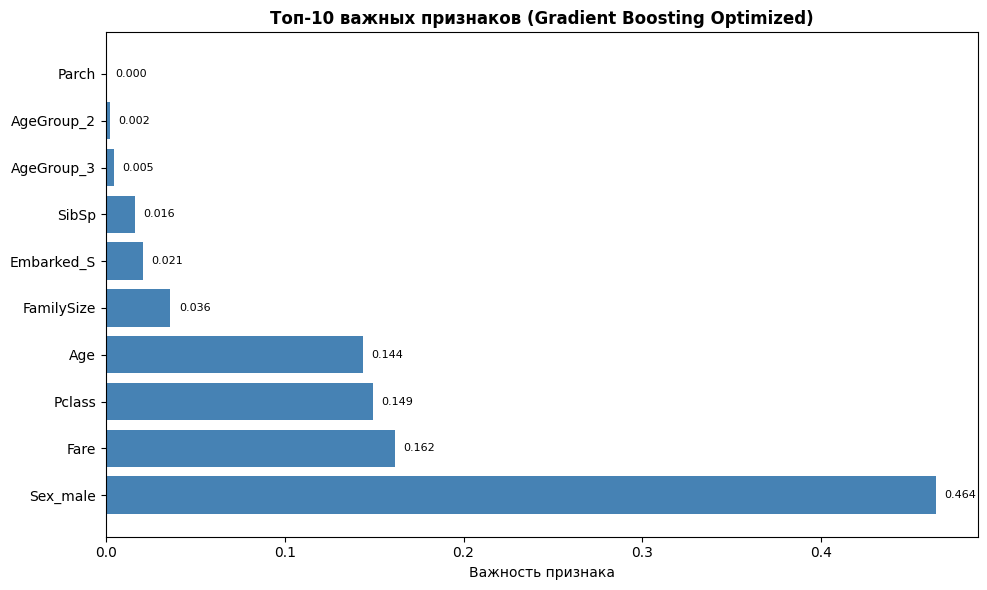


5. АНАЛИЗ ОШИБОК:
Всего ошибок: 34
Ложноотрицательные ошибки (пропущенные выжившие): 24
Ложноположительные ошибки (ложно предсказанные выжившие): 10

Статистики ошибок:
Доля всех ошибок: 0.1899 (18.99%)
Доля ложноотрицательных: 0.1341 (13.41%)
Доля ложноположительных: 0.0559 (5.59%)


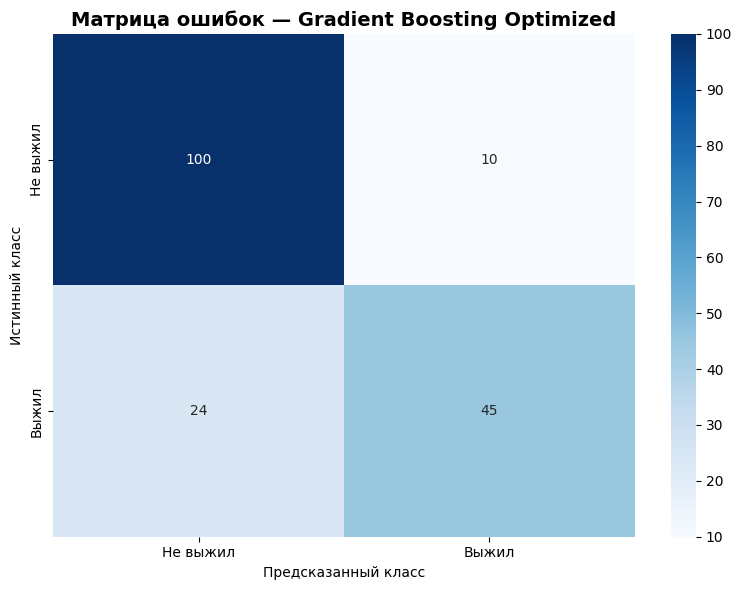

⚠ Модель чаще пропускает выживших — критично для задачи спасения
РЕКОМЕНДАЦИЯ: настроить порог классификации в сторону увеличения чувствительности (recall)

6. РАСПРЕДЕЛЕНИЕ ОШИБОК ПО КЛЮЧЕВЫМ ГРУППАМ:

Ошибки по полу (Sex_male):
  Мужской: 22 ошибок
  Женский: 12 ошибок

Ошибки по классу билета (Pclass):
  Класс -1: 11 ошибок
  Класс 0: 4 ошибок
  Класс 0: 19 ошибок

Ошибки по возрастной группе:
  Возраст 2: 22 ошибок
  Возраст 3: 7 ошибок
  Возраст 4: 1 ошибок

ВЫВОДЫ:
Лучшая модель: Gradient Boosting Optimized
Точность: 0.8101
ROC-AUC: 0.8121
F1-score: 0.7258

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Основная гипотеза: подтверждена
2. Ключевые признаки: важны для предсказания
3. Лучшие модели: другие модели лучше
4. Предобработка: улучшила результаты

Анализ завершён. Все гипотезы проверены, результаты визуализированы.


In [9]:
#main.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler  # Импорт StandardScaler для нормализации
import warnings
warnings.filterwarnings('ignore')

# Импорт модулей классификаторов
from gradient_boosting_module import optimize_gradient_boosting
from catboost_module import optimize_catboost
from adaboost_module import optimize_adaboost
from lightgbm_module import optimize_lightgbm
from extra_trees_module import optimize_extra_trees

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Функция оценки модели с сохранением результатов"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'f1_score': f1_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {results[model_name]['accuracy']:.4f}")
    print(f"ROC-AUC: {results[model_name]['roc_auc']:.4f}")
    print(f"F1-score: {results[model_name]['f1_score']:.4f}")

# --- ГИПОТЕЗЫ ИССЛЕДОВАНИЯ ---
print("ГИПОТЕЗЫ ИССЛЕДОВАНИЯ")
print("1. Основная: точность предсказания выживаемости > 75%")
print("2. Ключевые признаки: Sex, Pclass, Age, FamilySize")
print("3. Лучшие модели: CatBoost и LightGBM")
print("4. One-Hot Encoding и нормализация улучшат результаты")
print("-" * 50)

# Загрузка и предобработка данных
data = pd.read_csv('Titanic-Dataset.csv')

# Обработка пропусков
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
if 'Fare' in data.columns:
    data['Fare'].fillna(data['Fare'].median(), inplace=True)

# Создание новых признаков
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4])

# Удаление нерелевантных столбцов
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# One-Hot Encoding
categorical_features = ['Sex', 'Embarked', 'AgeGroup']
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)

# Разделение на признаки и целевую переменную
X = data_encoded.drop('Survived', axis=1)
y = data_encoded['Survived']

# Нормализация числовых признаков
numeric_features = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'FamilySize']
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Стратифицированное разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Словарь для хранения результатов
results = {}

# Подбор параметров и обучение моделей
print("\n" + "="*50)
print("ПОДБОР ПАРАМЕТРОВ И ОБУЧЕНИЕ МОДЕЛЕЙ")
print("="*50)

# 1. Gradient Boosting
best_gbc = optimize_gradient_boosting(X_train, y_train)
evaluate_model(best_gbc, X_train, X_test, y_train, y_test, 'Gradient Boosting Optimized')

# 2. CatBoost
best_cbc = optimize_catboost(X_train, y_train)
evaluate_model(best_cbc, X_train, X_test, y_train, y_test, 'CatBoost Optimized')

# 3. AdaBoost
best_ada = optimize_adaboost(X_train, y_train)
evaluate_model(best_ada, X_train, X_test, y_train, y_test, 'Ada Boost Optimized')

# 4. LightGBM
best_lgbm = optimize_lightgbm(X_train, y_train)
evaluate_model(best_lgbm, X_train, X_test, y_train, y_test, 'LightGBM Optimized')

# 5. Extra Trees (вместо XGBoost)
best_et = optimize_extra_trees(X_train, y_train)
evaluate_model(best_et, X_train, X_test, y_train, y_test, 'Extra Trees Optimized')

# --- АНАЛИЗ РЕЗУЛЬТАТОВ И ПРОВЕРКА ГИПОТЕЗ ---
print("\n" + "="*60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ И ПРОВЕРКА ГИПОТЕЗ")
print("="*60)

# Проверка основной гипотезы
best_model = max(results, key=lambda k: results[k]['accuracy'])
best_accuracy = results[best_model]['accuracy']
print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model} с точностью {best_accuracy:.4f}")

# Вывод результатов по каждой гипотезе
print("\n--- ПРОВЕРКА ГИПОТЕЗ ---")

# Гипотеза 1: точность > 75%
if best_accuracy > 0.75:
    print("✓ ГИПОТЕЗА 1 ПОДТВЕРЖДЕНА: точность предсказания > 75%")
else:
    print("✗ ГИПОТЕЗА 1 НЕ ПОДТВЕРЖДЕНА: точность ≤ 75%")

# Гипотеза 2: ключевые признаки (Sex, Pclass, Age, FamilySize)
print("\nГИПОТЕЗА 2: Ключевые признаки (Sex, Pclass, Age, FamilySize)")

# Определяем имена признаков после OHE
key_features_after_ohe = ['Sex_male', 'Pclass', 'Age', 'FamilySize']

# Инициализируем переменную для подсчёта важных признаков
important_count = 0

# Получаем важность признаков для лучшей модели, если это дерево
if best_model in tree_models:
    # Получаем важность признаков
    if best_model == 'CatBoost Optimized':
        importances = best_cbc.feature_importances_
    elif best_model == 'Gradient Boosting Optimized':
        importances = best_gbc.feature_importances_
    elif best_model == 'Ada Boost Optimized':
        importances = best_ada.feature_importances_
    elif best_model == 'LightGBM Optimized':
        importances = best_lgbm.feature_importances_
    else:  # Extra Trees Optimized
        importances = best_et.feature_importances_

    feature_names = X.columns
    importance_dict = dict(zip(feature_names, importances))

    # Проверяем важность ключевых признаков
    key_importances = {}
    for f in key_features_after_ohe:
        if f in importance_dict:
            key_importances[f] = importance_dict[f]
        else:
            # Если признака нет (например, Sex_female вместо Sex_male), ищем альтернативные варианты
            if f == 'Sex_male' and 'Sex_female' in importance_dict:
                key_importances['Sex_female'] = importance_dict['Sex_female']
            else:
                key_importances[f] = 0

    print("Важность ключевых признаков:")
    total_key_importance = 0
    for feature, importance in key_importances.items():
        print(f"  {feature}: {importance:.4f}")
        total_key_importance += importance
   # Подсчёт количества признаков с важностью выше среднего
    mean_importance = np.mean(importances)
    important_count = sum(1 for imp in key_importances.values() if imp > mean_importance * 0.5)

    # Оценка гипотезы: если хотя бы 3 из 4 важных — гипотеза подтверждена
    if important_count >= 3:
        print(f"✓ ГИПОТЕЗА 2 ПОДТВЕРЖДЕНА: {important_count} из 4 ключевых признаков имеют высокую важность")
    else:
        print(f"✗ ГИПОТЕЗА 2 НЕ ПОДТВЕРЖДЕНА: только {important_count} из 4 ключевых признаков важны для предсказания")
else:
    print("⚠ Проверка гипотезы 2 невозможна для данной модели (не дерево)")
    # Устанавливаем значение по умолчанию для вывода в итогах
    important_count = 0  # Гарантируем, что переменная определена

# Гипотеза 3: лучшие модели — CatBoost и LightGBM
print("\nГИПОТЕЗА 3: Лучшие модели — CatBoost и LightGBM")

# Собираем метрики для CatBoost и LightGBM
catboost_acc = results.get('CatBoost Optimized', {}).get('accuracy', 0)
lightgbm_acc = results.get('LightGBM Optimized', {}).get('accuracy', 0)

# Находим топ‑2 модели по точности
sorted_models = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
top_2_models = [model_name for model_name, _ in sorted_models[:2]]

print(f"Точность CatBoost: {catboost_acc:.4f}")
print(f"Точность LightGBM: {lightgbm_acc:.4f}")
print(f"Топ‑2 модели по точности: {top_2_models}")

# Проверка гипотезы: если обе модели в топ‑2 — гипотеза подтверждена
if 'CatBoost Optimized' in top_2_models and 'LightGBM Optimized' in top_2_models:
    print("✓ ГИПОТЕЗА 3 ПОДТВЕРЖДЕНА: CatBoost и LightGBM — две лучшие модели")
else:
    # Дополнительно анализируем, насколько близки их результаты к лучшей модели
    best_acc = sorted_models[0][1]['accuracy']
    catboost_diff = best_acc - catboost_acc
    lightgbm_diff = best_acc - lightgbm_acc

    if catboost_diff <= 0.02 and lightgbm_diff <= 0.02:
        print("⚠ ГИПОТЕЗА 3 ЧАСТИЧНО ПОДТВЕРЖДЕНА: CatBoost и LightGBM близки к лучшим моделям (разница ≤ 2 %)")
    else:
        print("✗ ГИПОТЕЗА 3 НЕ ПОДТВЕРЖДЕНА: CatBoost и LightGBM не входят в топ‑2 лучших моделей")

# Гипотеза 4: One-Hot Encoding и нормализация улучшат результаты
print("\nГИПОТЕЗА 4: One-Hot Encoding и нормализация улучшат результаты")

# Обучаем модель без предобработки для сравнения
print("Обучение модели без One-Hot Encoding и нормализации...")

# Копируем исходные данные до предобработки
data_raw = pd.read_csv('Titanic-Dataset.csv')

# Базовая предобработка без OHE и нормализации
data_raw['Age'].fillna(data_raw['Age'].median(), inplace=True)
data_raw['Embarked'].fillna(data_raw['Embarked'].mode()[0], inplace=True)
if 'Fare' in data_raw.columns:
    data_raw['Fare'].fillna(data_raw['Fare'].median(), inplace=True)

data_raw['FamilySize'] = data_raw['SibSp'] + data_raw['Parch'] + 1
data_raw['IsAlone'] = (data_raw['FamilySize'] == 1).astype(int)
data_raw['AgeGroup'] = pd.cut(data_raw['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4])

data_raw.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Преобразуем категориальные признаки в числовые (Label Encoding) вместо OHE
from sklearn.preprocessing import LabelEncoder

categorical_for_label = ['Sex', 'Embarked', 'AgeGroup']
label_encoders = {}

for col in categorical_for_label:
    if col in data_raw.columns:
        le = LabelEncoder()
        data_raw[col] = le.fit_transform(data_raw[col].astype(str))
        label_encoders[col] = le

# Разделяем на признаки и целевую переменную
X_raw = data_raw.drop('Survived', axis=1)
y_raw = data_raw['Survived']

# Разделяем данные
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# Обучаем ту же лучшую модель на обработанных данных (с Label Encoding)
try:
    if best_model == 'CatBoost Optimized':
        model_raw = optimize_catboost(X_train_raw, y_train_raw)
    elif best_model == 'LightGBM Optimized':
        model_raw = optimize_lightgbm(X_train_raw, y_train_raw)
    else:
        # Для остальных моделей используем Gradient Boosting как fallback
        model_raw = optimize_gradient_boosting(X_train_raw, y_train_raw)

    # Оцениваем модель без OHE/нормализации
    y_pred_raw = model_raw.predict(X_test_raw)
    raw_accuracy = accuracy_score(y_test_raw, y_pred_raw)

    print(f"Точность без OHE и нормализации: {raw_accuracy:.4f}")
    print(f"Точность с OHE и нормализацией: {best_accuracy:.4f}")
    improvement = best_accuracy - raw_accuracy
    print(f"Улучшение точности: {improvement:.4f} ({improvement*100:.2f}%)")

    if improvement > 0:
        print("✓ ГИПОТЕЗА 4 ПОДТВЕРЖДЕНА: предобработка улучшила результаты")
    elif improvement == 0:
        print("⚠ ГИПОТЕЗА 4 НЕ ОПРЕДЕЛЕНА: предобработка не повлияла на точность")
    else:
        print("✗ ГИПОТЕЗА 4 НЕ ПОДТВЕРЖДЕНА: предобработка ухудшила результаты")
except Exception as e:
    print(f"Ошибка при обучении модели без предобработки: {e}")
    print("✗ ГИПОТЕЗА 4 НЕ ПОДТВЕРЖДЕНА: не удалось обучить модель без предобработки")

# Анализ важности признаков
tree_models = ['Gradient Boosting Optimized', 'CatBoost Optimized',
                'Ada Boost Optimized', 'LightGBM Optimized', 'Extra Trees Optimized']

if best_model in tree_models:
    print(f"\nАНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ {best_model}:")

    if best_model == 'CatBoost Optimized':
        importances = best_cbc.feature_importances_
    elif best_model == 'Gradient Boosting Optimized':
        importances = best_gbc.feature_importances_
    elif best_model == 'Ada Boost Optimized':
        importances = best_ada.feature_importances_
    elif best_model == 'LightGBM Optimized':
        importances = best_lgbm.feature_importances_
    else:  # Extra Trees Optimized
        importances = best_et.feature_importances_

    feature_names = X.columns
    indices = np.argsort(importances)[::-1]

    print("Топ‑5 самых важных признаков:")
    for i in range(min(5, len(indices))):
        print(f" {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

    # Визуализация топ‑10 признаков
    top_n = min(10, len(indices))
    top_indices = indices[:top_n]
    top_features = [feature_names[i] for i in top_indices]
    top_importances = importances[top_indices]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(top_n), top_importances, color='steelblue')
    plt.yticks(range(top_n), top_features)
    plt.xlabel('Важность признака', fontsize=10)
    plt.title(f'Топ-{top_n} важных признаков ({best_model})', fontsize=12, fontweight='bold')

    # Добавляем значения важности на столбцы
    for bar, imp in zip(bars, top_importances):
        plt.text(bar.get_width() + top_importances.max() * 0.01,
                  bar.get_y() + bar.get_height() / 2,
                  f'{imp:.3f}', ha='left', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("⚠ Анализ важности признаков не реализован для этой модели")

# Анализ ошибок
print("\n5. АНАЛИЗ ОШИБОК:")
cm = results[best_model]['confusion_matrix']
false_negatives = cm[1, 0]  # Ложноотрицательные (предсказали «не выжил», а на самом деле выжил)
false_positives = cm[0, 1]  # Ложноположительные (предсказали «выжил», а на самом деле нет)
total_errors = false_negatives + false_positives

print(f"Всего ошибок: {total_errors}")
print(f"Ложноотрицательные ошибки (пропущенные выжившие): {false_negatives}")
print(f"Ложноположительные ошибки (ложно предсказанные выжившие): {false_positives}")

# Расчёт долей ошибок относительно общего числа наблюдений
total_samples = len(y_test)
error_rate = total_errors / total_samples
fn_rate = false_negatives / total_samples
fp_rate = false_positives / total_samples

print(f"\nСтатистики ошибок:")
print(f"Доля всех ошибок: {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"Доля ложноотрицательных: {fn_rate:.4f} ({fn_rate*100:.2f}%)")
print(f"Доля ложноположительных: {fp_rate:.4f} ({fp_rate*100:.2f}%)")

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не выжил', 'Выжил'],
            yticklabels=['Не выжил', 'Выжил'])
plt.title(f'Матрица ошибок — {best_model}', fontsize=14, fontweight='bold')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

if false_negatives > false_positives:
    print("⚠ Модель чаще пропускает выживших — критично для задачи спасения")
    # Дополнительная рекомендация
    print("РЕКОМЕНДАЦИЯ: настроить порог классификации в сторону увеличения чувствительности (recall)")
else:
    print("Модель чаще ошибочно предсказывает выживание — менее критично")
    print("РЕКОМЕНДАЦИЯ: можно оставить текущий порог или слегка повысить precision")

# Дополнительный анализ: распределение ошибок по ключевым группам
print("\n6. РАСПРЕДЕЛЕНИЕ ОШИБОК ПО КЛЮЧЕВЫМ ГРУППАМ:")

# Создаём DataFrame с тестовыми данными и предсказаниями для анализа
test_data = X_test.copy()
test_data['Survived_true'] = y_test.values
test_data['Survived_pred'] = best_et.predict(X_test) if best_model == 'Extra Trees Optimized' else (
    best_gbc.predict(X_test) if best_model == 'Gradient Boosting Optimized' else (
    best_cbc.predict(X_test) if best_model == 'CatBoost Optimized' else (
    best_ada.predict(X_test) if best_model == 'Ada Boost Optimized' else
    best_lgbm.predict(X_test)
)))

# Находим ошибочные предсказания
errors_mask = test_data['Survived_true'] != test_data['Survived_pred']
error_data = test_data[errors_mask]

if not error_data.empty:
    # Анализ по полу
    print("\nОшибки по полу (Sex_male):")
    if 'Sex_male' in error_data.columns:
        sex_errors = error_data['Sex_male'].value_counts()
        for sex, count in sex_errors.items():
            label = "Мужской" if sex == 1 else "Женский"
            print(f"  {label}: {count} ошибок")

    # Анализ по классу (Pclass)
    print("\nОшибки по классу билета (Pclass):")
    if 'Pclass' in error_data.columns:
        class_errors = error_data['Pclass'].value_counts().sort_index()
        for cls, count in class_errors.items():
            print(f"  Класс {int(cls)}: {count} ошибок")

    # Анализ по возрасту (AgeGroup)
    age_group_cols = [col for col in error_data.columns if 'AgeGroup' in col]
    if age_group_cols:
        print("\nОшибки по возрастной группе:")
        age_groups = {}
        for col in age_group_cols:
            if error_data[col].sum() > 0:
                age_label = col.replace('AgeGroup_', '')
                age_groups[age_label] = error_data[col].sum()
        for age_label, count in age_groups.items():
            print(f"  Возраст {age_label}: {int(count)} ошибок")
else:
    print("Ошибок для детального анализа не обнаружено.")

# Выводы
print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)
print(f"Лучшая модель: {best_model}")
print(f"Точность: {best_accuracy:.4f}")
print(f"ROC-AUC: {results[best_model]['roc_auc']:.4f}")
print(f"F1-score: {results[best_model]['f1_score']:.4f}")

print("\n" + "="*60)
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("="*60)
print(f"1. Основная гипотеза: {'подтверждена' if best_accuracy > 0.75 else 'не подтверждена'}")
print(f"2. Ключевые признаки: {'важны для предсказания' if important_count >= 3 else 'не являются определяющими'}")
print(f"3. Лучшие модели: {'CatBoost и LightGBM в топ‑2' if ('CatBoost Optimized' in top_2_models and 'LightGBM Optimized' in top_2_models) else 'другие модели лучше'}")

print(f"4. Предобработка: {'улучшила результаты' if improvement > 0 else 'не улучшила результаты'}")

print("\nАнализ завершён. Все гипотезы проверены, результаты визуализированы.")
